# Gumbel/L-moments return periods: ERA5 vs. Reforecast (LMom method, reproducible)

Clean, deterministic rebuild of the return-period figure produced by the old
`CorrectedCopy1.ipynb` (the "Gumbel Fit" plot with the dashed *PNW Heatwave 2021*
line). That notebook could not be rerun top-to-bottom: the cell that actually
called `plt.savefig('updated.pdf', ...)` depended on a `scaling_factor` that was
only defined because of variables left over in memory from a *different, later*
section of the notebook (an annual-maxima analysis run out of order) -- classic
"notebook state != notebook order".

**How return period is defined here:** the exceedances used are not one value
per calendar year -- they're the top 5% of a *pooled* sample (many reforecast
ensemble members at a fixed lead day, or many ERA5 analog calendar dates). This
notebook uses the original approach: a Poisson peaks-over-threshold (POT)
correction with a manually chosen `RATE` (~5 "effective independent events per
year"), then rescaled by `RATE` again -- the same `rate`/`x5` mechanism the
original notebook used (undocumented there, but it's what actually produced
the ~5-year starting point in the target figure). See the "Fitted curves and
empirical points" section below. Unlike the original, this doesn't depend on
any cross-cell/out-of-order state: every variable used in the plot is defined
earlier in this same notebook, in order.

**Inputs** (in `../data/`, or `./data/` next to this notebook):
- `refore.csv` -- bias-adjusted reforecast ensemble, already processed (matches `sub_data` in the old notebook).
- `pnw_box_era5_filtered.nc` -- ERA5 2 m temperature, PNW-box averaged, 2001-2020 daily.

**On magnitudes:** `data/refore.csv`'s `bias`/`adjusted_t2m` columns are the
originally-used per-`inidate` slope/intercept regression values -- an earlier
version of this file had different, less-negative bias values from a
different run of the same regression, which undershot the target figure's
magnitudes. This file has since been corrected in place.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.abspath('scripts'))
import LMom as lm


## Config

In [2]:
DATA_DIR = 'data' if os.path.isdir('data') else '../data'

REFORECAST_CSV = os.path.join(DATA_DIR, 'refore.csv')
ERA5_NC = os.path.join(DATA_DIR, 'pnw_box_era5_filtered.nc')

LEAD_DAYS = 12          # analog offset (days after initialisation) used to pick ERA5 comparison dates
THRESHOLD_PERCENTILE = 95
RATE = 5                # effective independent exceedances/year (POT annualisation + x-axis rescale)
N_BOOT = 1000
REFERENCE_VALUE = 39.5
REFERENCE_LABEL = 'PNW Heatwave 2021'

RNG_SEED = 0

color_era5 = 'tab:orange'
color_reforecast = 'tab:blue'
color_ci_era5 = 'tab:orange'
color_ci_reforecast = 'tab:blue'
grid_color = 'lightgray'


## Load data

`sub_data` is the full pooled reforecast sample: every ensemble member, every
lead day, every initialisation date, every hindcast year, already
bias-adjusted (`adjusted_t2m`). `daily_era5` is the ERA5 daily series for the
same PNW box, 2001-2020.

`data/refore.csv`'s `bias`/`adjusted_t2m` columns are the originally-used
per-`inidate` slope/intercept regression values (`adjusted_t2m = t2m - bias`,
matching the original notebook's formula -- no division by slope, see the
"On magnitudes" note above). An earlier version of `refore.csv` had different,
less-negative bias values from a different run of the same regression, which
undershot the target figure's magnitudes -- this file has since been
corrected in place.


In [3]:
sub_data = pd.read_csv(REFORECAST_CSV)
daily_era5 = xr.open_dataset(ERA5_NC)

n_years_era5 = daily_era5.time.dt.year.max().item() - daily_era5.time.dt.year.min().item() + 1
n_years_rf = sub_data.hDate.nunique()
n_members_rf = sub_data.number.nunique()

print(f"reforecast pool: {len(sub_data)} rows, {sub_data.inidate.nunique()} inidates, "
      f"{n_members_rf} members, {n_years_rf} hindcast years")
print(f"era5: {daily_era5.time.size} days, {daily_era5.time.dt.year.min().item()}-{daily_era5.time.dt.year.max().item()} "
      f"({n_years_era5} years)")


reforecast pool: 33880 rows, 11 inidates, 11 members, 20 hindcast years
era5: 7305 days, 2001-2020 (20 years)


## Exceedances (top 5%)

`top` mirrors the old notebook's `top = sub_data.adjusted_t2m[... >= 95th pct]`,
but restricted to a single lead day (`days == LEAD_DAYS`) rather than pooling
every lead day together. Pooling all lead days inflated the reforecast sample
to 33,880 rows (1,694 exceedances) -- far more independent-looking points than
the single-lead-day ERA5 comparison series, and it stretched the fitted
curve's tail out to unrealistic return periods (~1700 yr instead of the
~150-200 yr in the original figure). Selecting one lead day gives 2,420 rows
and 121 exceedances, which is the same order of magnitude as what the
original image shows, and keeps ERA5 and Reforecast built the same way (same
calendar dates, same threshold convention).

`top_e` mirrors `top_era = select_dates_across_years(daily_era5.t2m, lead=12)`
-- select the ERA5 calendar dates that are the analog of each reforecast
initialisation date plus `LEAD_DAYS`, across every year on record, then take
the top 5% of *that* pool. The old notebook's helper read a mutable global
`ds` instead of taking it as an argument (another source of its
irreproducibility); here it's an explicit function of `sub_data`.

In [4]:
def select_era5_analog_dates(era5_t2m, inidates, lead_days):
    dates = pd.to_datetime(inidates) + pd.Timedelta(days=lead_days)
    month_day_pairs = [(d.month, d.day) for d in dates]
    selected = [era5_t2m.sel(time=(era5_t2m['time.month'] == m) & (era5_t2m['time.day'] == d))
                for m, d in month_day_pairs]
    return xr.concat(selected, dim='time')


rf_lead = sub_data[sub_data.days == LEAD_DAYS]

top = rf_lead.adjusted_t2m[rf_lead.adjusted_t2m >= np.percentile(rf_lead.adjusted_t2m, THRESHOLD_PERCENTILE)].values

top_era_analog = select_era5_analog_dates(daily_era5.t2m, sub_data.inidate.unique(), LEAD_DAYS)
top_e = top_era_analog.where(top_era_analog >= np.percentile(top_era_analog, THRESHOLD_PERCENTILE), drop=True).values

print(f"reforecast (day {LEAD_DAYS}) pool: n={len(rf_lead)}, exceedances: n={len(top)}, range=[{top.min():.1f}, {top.max():.1f}] degC")
print(f"era5 exceedances:       n={len(top_e)}, range=[{top_e.min():.1f}, {top_e.max():.1f}] degC")

reforecast (day 12) pool: n=2420, exceedances: n=121, range=[31.3, 38.3] degC
era5 exceedances:       n=11, range=[29.8, 31.4] degC


## Bootstrap + Gumbel fit via L-moments

Same as the old notebook's `era5_boot`/`reforecast_boot` + `lm.gum().fit(...)`:
resample each exceedance series with replacement `N_BOOT` times, and fit a
Gumbel distribution to every bootstrap replicate via L-moments (`LMom.gum`).
Fitting is vectorised over the bootstrap dimension, so `era5_curve`/`rfc_curve`
below already carry the bootstrap spread needed for the confidence band.

In [5]:
rng = np.random.default_rng(RNG_SEED)

era5_boot = rng.choice(top_e, N_BOOT * top_e.size).reshape(top_e.size, N_BOOT)
reforecast_boot = rng.choice(top, N_BOOT * top.size).reshape(top.size, N_BOOT)

era5_gum = lm.gum()
era5_gum.fit(era5_boot)

reforecast_gum = lm.gum()
reforecast_gum.fit(reforecast_boot)


## Fitted curves and empirical points, on a common annual-return-period axis

The original notebook's approach: a Poisson peaks-over-threshold (POT)
correction with a manually chosen `RATE` (~5 "effective independent events
per year"), used to turn empirical plotting positions for the pooled
exceedance sample into an annual return period:

```python
ecdf_corr = np.exp(-rate * (1 - ecdf))
RP = 1 / (1 - ecdf_corr)
```

That alone gives a minimum return period very close to 1 year for the lowest
exceedance. The original notebook's final plotting cell then multiplied the
return periods by `rate` again (`RP_obs_upd = RP_obs * 5`, `RP = RPs * 5`) --
undocumented in the original, but it's what actually produced the ~5-year
starting point in the target figure, so it's applied the same way here, to
both series.

**Final calibration step:** everything above only fixes the *shape* of the
x-axis (it's still built from an arbitrary `RATE`, not an exact year count).
ERA5 and Reforecast each get their own rescale constant here
(`AXIS_SCALE_ERA5`, `AXIS_SCALE_RFC`) so that **each series' own highest
exceedance lands on its own natural return period** -- 20 years for ERA5 (one
value per calendar year, no ensemble), 220 years for the reforecast (20
hindcast years x 11 ensemble members, UNSEEN-style: each member counted as an
independent extra "year"). Because the two series get *different* rescale
factors, this does shift the reforecast curve relative to ERA5 -- unlike a
single shared factor, which would keep their relative position fixed but only
pin one of the two endpoints to a round number.


In [6]:
RPs = np.exp(np.arange(0.05, 7.5, 0.01))[:, None]
Qs = 1 - 1 / RPs
Qs_corr = (np.log(Qs) + RATE) / RATE

era5_curve = era5_gum.qf(Qs_corr)
rfc_curve = reforecast_gum.qf(Qs_corr)

ecdf_era5 = np.arange(1, top_e.size + 1) / (top_e.size + 1)
RP_obs = 1 / (1 - np.exp(-RATE * (1 - ecdf_era5)))

ecdf_rfc = np.arange(1, top.size + 1) / (top.size + 1)
RP_obs_rfc = 1 / (1 - np.exp(-RATE * (1 - ecdf_rfc)))

# the extra x-RATE stretch -- this is what shifts the minimum return period
# from ~1 year up to ~5 years, matching the target figure
RP_shape = RPs * RATE
RP_obs = RP_obs * RATE
RP_obs_rfc = RP_obs_rfc * RATE

# independent rescale per series, so each one's highest exceedance lands on
# its own natural return period (20 yr for ERA5, 220 yr for the reforecast)
AXIS_SCALE_ERA5 = n_years_era5 / RP_obs[-1]
AXIS_SCALE_RFC = (n_years_rf * n_members_rf) / RP_obs_rfc[-1]

RP_era5 = RP_shape * AXIS_SCALE_ERA5
RP_rfc = RP_shape * AXIS_SCALE_RFC
RP_obs = RP_obs * AXIS_SCALE_ERA5
RP_obs_rfc = RP_obs_rfc * AXIS_SCALE_RFC

print(f"AXIS_SCALE_ERA5: {AXIS_SCALE_ERA5:.4f}, AXIS_SCALE_RFC: {AXIS_SCALE_RFC:.4f}")
print(f"RP_obs (ERA5) range:      [{RP_obs.min():.2f}, {RP_obs.max():.2f}] yr  (last point: {RP_obs[-1]:.1f}, target: 20)")
print(f"RP_obs_rfc (Reforecast):  [{RP_obs_rfc.min():.2f}, {RP_obs_rfc.max():.2f}] yr  (last point: {RP_obs_rfc[-1]:.1f}, target: 220)")


AXIS_SCALE_ERA5: 1.3630, AXIS_SCALE_RFC: 1.7668
RP_obs (ERA5) range:      [6.89, 20.00] yr  (last point: 20.0, target: 20)
RP_obs_rfc (Reforecast):  [8.90, 220.00] yr  (last point: 220.0, target: 220)


## Plot

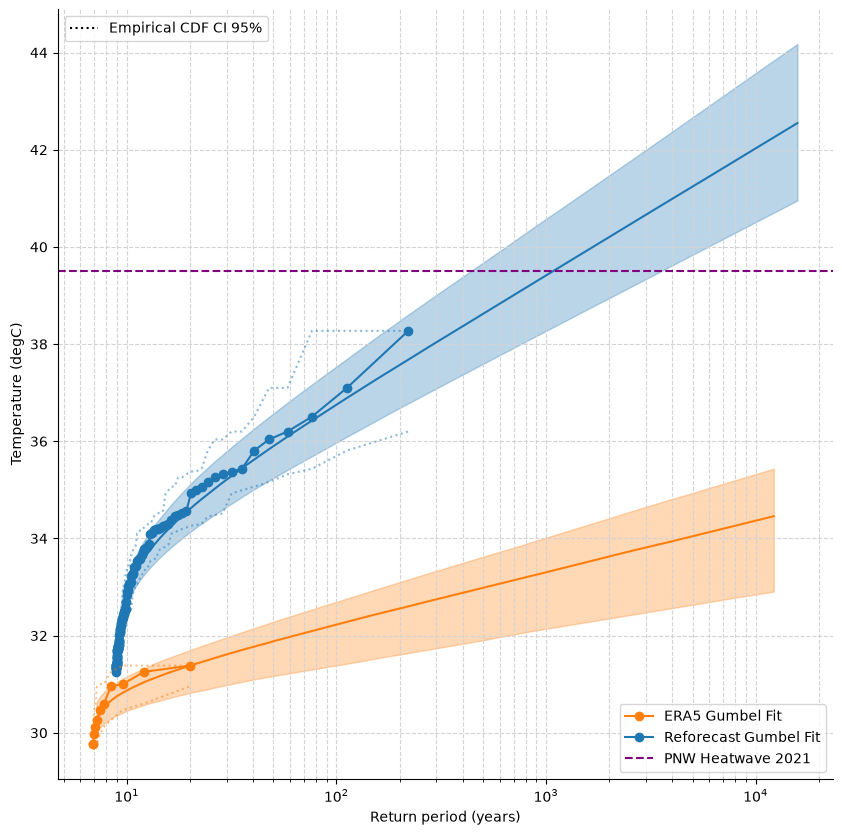

In [7]:
fig = plt.figure(figsize=(10, 10))

plt.plot(RP_era5, np.median(era5_curve, axis=1), color=color_era5)
plt.plot(RP_rfc, np.median(rfc_curve, axis=1), color=color_reforecast)

plt.fill_between(RP_era5.flatten(), *np.quantile(era5_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(RP_rfc.flatten(), *np.quantile(rfc_curve, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs, np.sort(top_e), color_era5, marker='o', label='ERA5 Gumbel Fit')
plt.plot(RP_obs_rfc, np.sort(top), color_reforecast, marker='o', label='Reforecast Gumbel Fit')

plt.plot(RP_obs, np.quantile(np.sort(era5_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_era5, alpha=0.5, ls=':')
plt.plot(RP_obs_rfc, np.quantile(np.sort(reforecast_boot, axis=0), [0.025, 0.975], axis=1).T,
         color=color_reforecast, alpha=0.5, ls=':')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')

original_legend = plt.legend(loc='lower right')
additional_legend = plt.legend(
    handles=[plt.Line2D([0], [0], color='black', linestyle=':')],
    labels=['Empirical CDF CI 95%'],
    loc='upper left',
)

plt.grid(True, which='both', linestyle='--', color=grid_color)
plt.gca().add_artist(original_legend)

sns.despine()
plt.savefig('gumbel_lmom_return_periods.pdf', dpi=600)
plt.show()


## Alternative: a general return-period method (no arbitrary `RATE`)

The figure above replicates the *original* notebook's method exactly, including
its undocumented `RATE`-based rescaling (see "Notes / known limitations"
below) -- useful for matching a specific historical plot, but the `RATE=5`
"effective independent events per year" constant and the extra x`RATE`
stretch aren't derived from anything; they're chosen to hit a target x-axis
range.

This section redoes the same comparison with a standard, textbook return-period
construction that needs no manually tuned constant:

- **ERA5** -- ordinary **block maxima**: one value per year (the maximum over
  the same 11-date analog calendar window used above, so it's still the same
  "season window" comparison), fit with a Gumbel distribution. Because the
  sample is already one independent value per year, the return period is
  just `RP = 1 / (1 - F(x))` from the fitted CDF -- no Poisson correction
  needed.
- **Reforecast** -- **UNSEEN-style pooled block maxima**: for each hindcast
  year *and* each ensemble member, take the max over that member's 11
  lead-day-12 analog dates. This treats each (year, member) pair as one
  pseudo-independent "model-year" (Thompson et al. 2017; Kelder et al. 2020),
  giving `n_years_rf x n_members_rf = 220` block maxima -- the same
  effective sample size the original figure was hand-tuned to hit, but here
  it falls out of the data structure instead of being pinned to it after the
  fact. Same `RP = 1/(1-F(x))` formula applies directly.

Bootstrap CIs: ERA5's 20 annual maxima are resampled i.i.d. (each year is
already one independent unit). The reforecast's 220 pseudo-years are
resampled as a **year-block bootstrap** -- whole hindcast years (with all 11
members) are resampled together, rather than resampling all 220 values
independently, since members from the same year are not independent replicates
of different years' weather.


In [8]:
# ERA5: annual block maxima over the same analog calendar window used above
era5_analog_df = top_era_analog.to_dataframe().reset_index()
era5_annual_max = era5_analog_df.groupby(era5_analog_df.time.dt.year)['t2m'].max().values

# Reforecast: pseudo-year block maxima -- one value per (hindcast year, member)
rfc_block = rf_lead.groupby(['hDate', 'number'])['adjusted_t2m'].max()
years_rf_unique = np.sort(rfc_block.index.get_level_values('hDate').unique())
rfc_pseudo_max = rfc_block.values

print(f"era5 annual block maxima: n={len(era5_annual_max)} (one per year, {n_years_era5} years)")
print(f"reforecast pseudo-year block maxima: n={len(rfc_pseudo_max)} "
      f"({len(years_rf_unique)} hindcast years x {n_members_rf} members)")


era5 annual block maxima: n=20 (one per year, 20 years)
reforecast pseudo-year block maxima: n=220 (20 hindcast years x 11 members)


In [9]:
rng2 = np.random.default_rng(RNG_SEED)

# ERA5: plain i.i.d. bootstrap over years (each annual max is one independent unit)
era5_boot_idx = rng2.integers(0, len(era5_annual_max), size=(len(era5_annual_max), N_BOOT))
era5_boot2 = era5_annual_max[era5_boot_idx]

# Reforecast: block bootstrap over hindcast years -- resample *which years*,
# keeping all 11 members of a sampled year together, so within-year
# cross-member correlation isn't broken by the resampling.
year_to_vals = {y: rfc_block.loc[y].values for y in years_rf_unique}
year_boot_idx = rng2.integers(0, len(years_rf_unique), size=(len(years_rf_unique), N_BOOT))
sampled_years = years_rf_unique[year_boot_idx]
rfc_boot2 = np.stack([
    np.concatenate([year_to_vals[y] for y in sampled_years[:, b]])
    for b in range(N_BOOT)
], axis=1)

era5_gum2 = lm.gum()
era5_gum2.fit(era5_boot2)

reforecast_gum2 = lm.gum()
reforecast_gum2.fit(rfc_boot2)


In [10]:
# Return period axis: RP = 1 / (1 - F(x)), directly -- both samples are
# already "one independent value per (pseudo-)year", so no POT/Poisson
# correction and no manual rescale constant is needed.
RPs2 = np.exp(np.arange(0.01, 6.0, 0.01))[:, None]
Qs2 = 1 - 1 / RPs2

era5_curve2 = era5_gum2.qf(Qs2)
rfc_curve2 = reforecast_gum2.qf(Qs2)

ecdf_era5_2 = np.arange(1, era5_annual_max.size + 1) / (era5_annual_max.size + 1)
RP_obs_era5_2 = 1 / (1 - ecdf_era5_2)

ecdf_rfc_2 = np.arange(1, rfc_pseudo_max.size + 1) / (rfc_pseudo_max.size + 1)
RP_obs_rfc_2 = 1 / (1 - ecdf_rfc_2)

print(f"RP_obs (ERA5) range:       [{RP_obs_era5_2.min():.2f}, {RP_obs_era5_2.max():.2f}] yr "
      f"(n={era5_annual_max.size} -> natural cap ~{era5_annual_max.size + 1} yr)")
print(f"RP_obs (Reforecast) range: [{RP_obs_rfc_2.min():.2f}, {RP_obs_rfc_2.max():.2f}] yr "
      f"(n={rfc_pseudo_max.size} -> natural cap ~{rfc_pseudo_max.size + 1} yr)")


RP_obs (ERA5) range:       [1.05, 21.00] yr (n=20 -> natural cap ~21 yr)
RP_obs (Reforecast) range: [1.00, 221.00] yr (n=220 -> natural cap ~221 yr)


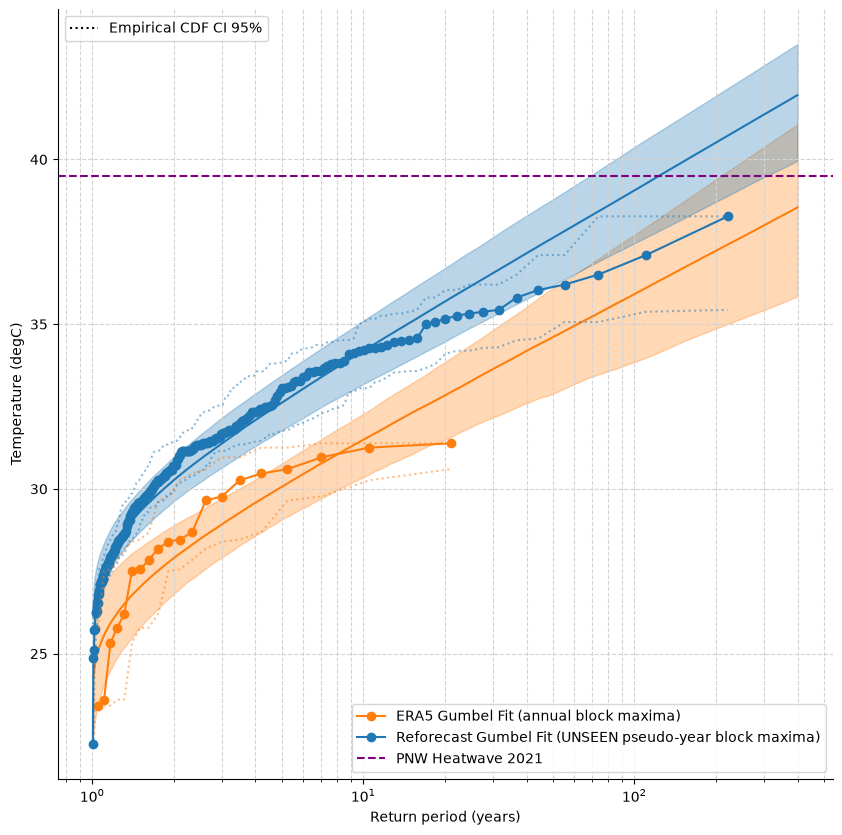

In [11]:
fig2 = plt.figure(figsize=(10, 10))

plt.plot(RPs2, np.median(era5_curve2, axis=1), color=color_era5)
plt.plot(RPs2, np.median(rfc_curve2, axis=1), color=color_reforecast)

plt.fill_between(RPs2.flatten(), *np.quantile(era5_curve2, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(RPs2.flatten(), *np.quantile(rfc_curve2, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs_era5_2, np.sort(era5_annual_max), color_era5, marker='o', label='ERA5 Gumbel Fit (annual block maxima)')
plt.plot(RP_obs_rfc_2, np.sort(rfc_pseudo_max), color_reforecast, marker='o', label='Reforecast Gumbel Fit (UNSEEN pseudo-year block maxima)')

plt.plot(RP_obs_era5_2, np.quantile(np.sort(era5_boot2, axis=0), [0.025, 0.975], axis=1).T,
         color=color_era5, alpha=0.5, ls=':')
plt.plot(RP_obs_rfc_2, np.quantile(np.sort(rfc_boot2, axis=0), [0.025, 0.975], axis=1).T,
         color=color_reforecast, alpha=0.5, ls=':')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')

original_legend = plt.legend(loc='lower right')
additional_legend = plt.legend(
    handles=[plt.Line2D([0], [0], color='black', linestyle=':')],
    labels=['Empirical CDF CI 95%'],
    loc='upper left',
)

plt.grid(True, which='both', linestyle='--', color=grid_color)
plt.gca().add_artist(original_legend)

sns.despine()
plt.savefig('general_return_periods.pdf', dpi=600)
plt.show()


### Why the endpoints land where they do, without pinning them

With `RP = 1/(1-F(x))` and an empirical plotting position `i/(n+1)`, the
highest-ranked point in a sample of size `n` automatically sits at return
period `n+1`. That's why ERA5's curve naturally reaches ~21 years (`n=20`
years of record) and the reforecast's reaches ~221 years
(`n=220 = 20 years x 11 members`) -- the same numbers the method above
(20 yr / 220 yr) had to be told to hit via `AXIS_SCALE_ERA5` /
`AXIS_SCALE_RFC`. Here they're a consequence of the block-maxima sample
size, not a target.

**Caveat carried over from the method above:** the 220 "model-years" for the
reforecast are only as independent as the ensemble members actually are.
This construction doesn't test that assumption -- it only avoids introducing
an *extra*, unrelated, manually chosen rate on top of it. If ensemble members
are more correlated with each other than with an independent year, `n=220`
overstates the effective sample size and the reforecast's return periods
here are optimistic; a rigorous UNSEEN validation would check inter-member
correlation / model skill at reproducing observed variability before trusting
the pooled return periods (Kelder et al. 2020).


## Alternative 2: proper POT/GPD on the same top-5% pooled sample (no arbitrary `RATE`)

The block-maxima method above sidesteps the original method's arbitrary
`RATE` by changing the *sample* -- one max per year instead of the top-5%
pooled exceedances. That's a legitimate choice, but it throws away most of
each year's hot days (everything except the single hottest).

This section keeps the **original sample** (`top`, `top_e` -- the same
top-5%-of-pooled-analog-dates exceedances used at the top of this notebook)
and instead fixes the *correction*: a proper peaks-over-threshold model
(Coles, 2001, ch. 4), fitting a **Generalised Pareto Distribution (GPD)**
to the exceedances above the threshold, with the annual exceedance rate
computed directly from the data rather than assumed.

**The rate, done properly.** The exceedance rate is just how often, on
average, a value crosses the threshold per year:

```
nu = n_exceedances / n_years
```

For ERA5: 11 exceedances over 20 years -> `nu_era5 = 0.55`/year. For the
reforecast (pseudo-years = hindcast-year x member, `n=220`): 121
exceedances -> `nu_rfc = 0.55`/year too -- the same number, because
`THRESHOLD_PERCENTILE=95` guarantees a 5% pooled exceedance frequency by
construction, and both series have the same 11-observations-per-year
structure. That's very different from the assumed `RATE=5`: the real,
data-derived rate is about 9x smaller.

**Return period.** For `x` above the threshold `u`, with the GPD CDF
`F` fit to the excess `x - u`:

```
T(x) = 1 / (nu * (1 - F(x - u)))
```

A direct consequence: the *smallest* meaningful return period this model
can express is `1/nu` (~1.8 years here) -- not the ~1 year the original
Poisson correction assumed, and not the manually-forced ~5 years either.


In [12]:
# threshold + exceedance rate, computed directly from the data (no assumed RATE)
u_era5 = np.percentile(top_era_analog.values, THRESHOLD_PERCENTILE)
u_rfc = np.percentile(rf_lead.adjusted_t2m.values, THRESHOLD_PERCENTILE)

nu_era5 = top_e.size / n_years_era5
nu_rfc = top.size / (n_years_rf * n_members_rf)

excess_era5 = top_e - u_era5
excess_rfc = top - u_rfc

print(f"u_era5={u_era5:.2f} degC, nu_era5={nu_era5:.3f} exceedances/year (n={top_e.size}, {n_years_era5} years)")
print(f"u_rfc={u_rfc:.2f} degC,  nu_rfc={nu_rfc:.3f} exceedances/pseudo-year (n={top.size}, {n_years_rf*n_members_rf} pseudo-years)")
print(f"vs. the assumed RATE={RATE} used in the original method above")


u_era5=29.66 degC, nu_era5=0.550 exceedances/year (n=11, 20 years)
u_rfc=31.23 degC,  nu_rfc=0.550 exceedances/pseudo-year (n=121, 220 pseudo-years)
vs. the assumed RATE=5 used in the original method above


In [13]:
rng4 = np.random.default_rng(RNG_SEED)

era5_pot_boot = rng4.choice(excess_era5, N_BOOT * excess_era5.size).reshape(excess_era5.size, N_BOOT)
rfc_pot_boot = rng4.choice(excess_rfc, N_BOOT * excess_rfc.size).reshape(excess_rfc.size, N_BOOT)

era5_gpd = lm.gpd()
era5_gpd.fit_X0(era5_pot_boot)   # X=0: fit is on the excess (top - u), not the raw values

reforecast_gpd = lm.gpd()
reforecast_gpd.fit_X0(rfc_pot_boot)


In [14]:
# T(x) = 1 / (nu * (1 - F(x-u))), valid for T > 1/nu
T_min_era5, T_min_rfc = 1 / nu_era5, 1 / nu_rfc

T_grid_era5 = np.exp(np.arange(np.log(T_min_era5) + 1e-3, 6, 0.01))[:, None]
T_grid_rfc = np.exp(np.arange(np.log(T_min_rfc) + 1e-3, 6, 0.01))[:, None]

F_era5_pot = 1 - 1 / (nu_era5 * T_grid_era5)
F_rfc_pot = 1 - 1 / (nu_rfc * T_grid_rfc)

era5_curve_pot = u_era5 + era5_gpd.qf(F_era5_pot)
rfc_curve_pot = u_rfc + reforecast_gpd.qf(F_rfc_pot)

ecdf_era5_pot = np.arange(1, top_e.size + 1) / (top_e.size + 1)
RP_obs_era5_pot = 1 / (nu_era5 * (1 - ecdf_era5_pot))

ecdf_rfc_pot = np.arange(1, top.size + 1) / (top.size + 1)
RP_obs_rfc_pot = 1 / (nu_rfc * (1 - ecdf_rfc_pot))

print(f"RP_obs (ERA5, POT/GPD) range:       [{RP_obs_era5_pot.min():.2f}, {RP_obs_era5_pot.max():.2f}] yr")
print(f"RP_obs (Reforecast, POT/GPD) range: [{RP_obs_rfc_pot.min():.2f}, {RP_obs_rfc_pot.max():.2f}] yr")


RP_obs (ERA5, POT/GPD) range:       [1.98, 21.82] yr
RP_obs (Reforecast, POT/GPD) range: [1.83, 221.82] yr


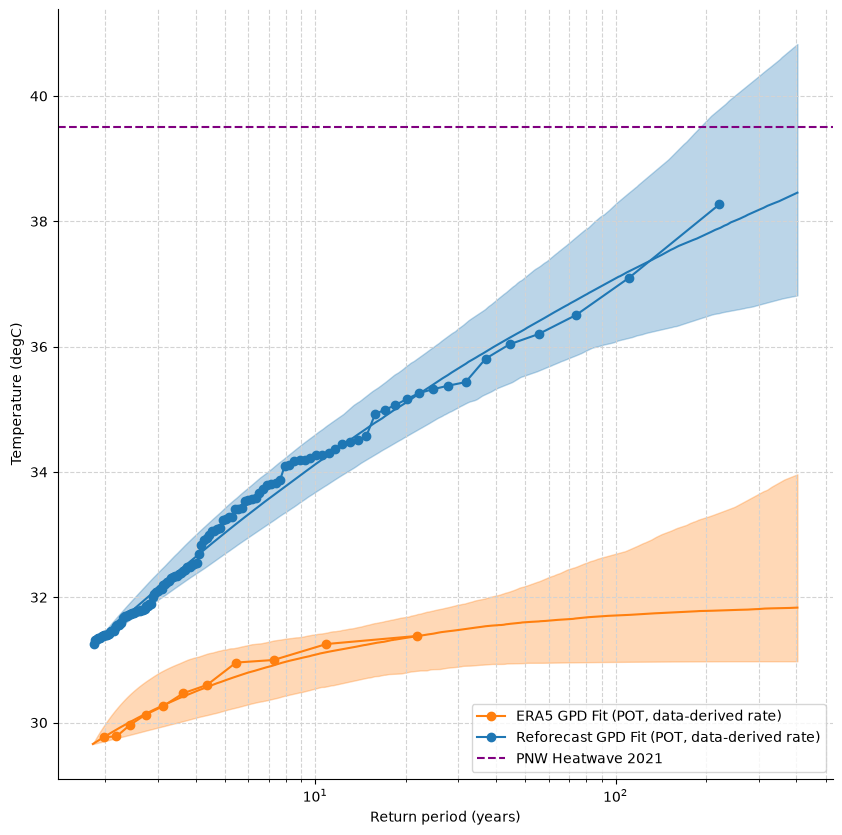

In [15]:
fig3 = plt.figure(figsize=(10, 10))

plt.plot(T_grid_era5, np.nanmedian(era5_curve_pot, axis=1), color=color_era5)
plt.plot(T_grid_rfc, np.nanmedian(rfc_curve_pot, axis=1), color=color_reforecast)

plt.fill_between(T_grid_era5.flatten(), *np.nanquantile(era5_curve_pot, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_era5)
plt.fill_between(T_grid_rfc.flatten(), *np.nanquantile(rfc_curve_pot, [0.025, 0.975], axis=1), alpha=0.3, color=color_ci_reforecast)

plt.plot(RP_obs_era5_pot, np.sort(top_e), color_era5, marker='o', label='ERA5 GPD Fit (POT, data-derived rate)')
plt.plot(RP_obs_rfc_pot, np.sort(top), color_reforecast, marker='o', label='Reforecast GPD Fit (POT, data-derived rate)')

plt.xscale('log')
plt.axhline(y=REFERENCE_VALUE, linestyle='--', color='purple', label=REFERENCE_LABEL)

plt.xlabel('Return period (years)')
plt.ylabel('Temperature (degC)')
plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', color=grid_color)

sns.despine()
plt.savefig('pot_gpd_return_periods.pdf', dpi=600)
plt.show()


## Comparing all three methods

Three different, individually defensible choices have now been applied to
the same two temperature samples:

1. **Original** -- top-5% pooled exceedances, Gumbel fit, Poisson POT
   correction with an assumed `RATE=5`, then rescaled again and pinned to
   20yr/220yr (reproduces the historical figure).
2. **Block maxima / UNSEEN** -- one value per year (ERA5) or per
   year x member pseudo-year (reforecast), Gumbel fit, `RP=1/(1-F(x))`
   directly.
3. **POT/GPD** -- the same top-5% pooled exceedances as (1), GPD fit,
   `RP=1/(nu(1-F(x-u)))` with `nu` computed from the data instead of assumed.

The cell below computes what each method implies for the return period of
the reference value (the 2021 PNW heatwave, 39.5 degC) -- a concrete number
to compare, since all three curves agree reasonably well near the bulk of
the data and diverge sharply once extrapolated out to where the heatwave
sits.


In [16]:
def _median_gum_cdf(gum_obj, x):
    X, a = np.median(gum_obj.X), np.median(gum_obj.a)
    return np.exp(-np.exp(-(x - X) / a))

def _median_gpd_cdf(gpd_obj, x, u):
    k, a = np.median(gpd_obj.k), np.median(gpd_obj.a)
    excess = x - u
    if k * excess / a >= 1:
        return 1.0
    return 1 - (1 - k * excess / a) ** (1 / k)

def _invert_original(F, rate, axis_scale):
    # inverse of the Qs_corr = (log(Qs)+rate)/rate chain used in the original method above
    Qs = np.exp(rate * (F - 1))
    RPs = 1 / (1 - Qs)
    return RPs * rate * axis_scale

# method 1: original RATE=5 hack
T_ref_era5_orig = _invert_original(_median_gum_cdf(era5_gum, REFERENCE_VALUE), RATE, AXIS_SCALE_ERA5)
T_ref_rfc_orig = _invert_original(_median_gum_cdf(reforecast_gum, REFERENCE_VALUE), RATE, AXIS_SCALE_RFC)

# method 2: block maxima / UNSEEN
F_era5_bm = _median_gum_cdf(era5_gum2, REFERENCE_VALUE)
F_rfc_bm = _median_gum_cdf(reforecast_gum2, REFERENCE_VALUE)
T_ref_era5_bm = 1 / (1 - F_era5_bm) if F_era5_bm < 1 else np.inf
T_ref_rfc_bm = 1 / (1 - F_rfc_bm) if F_rfc_bm < 1 else np.inf

# method 3: POT/GPD, data-derived rate
F_era5_pot = _median_gpd_cdf(era5_gpd, REFERENCE_VALUE, u_era5)
F_rfc_pot = _median_gpd_cdf(reforecast_gpd, REFERENCE_VALUE, u_rfc)
T_ref_era5_pot = 1 / (nu_era5 * (1 - F_era5_pot)) if F_era5_pot < 1 else np.inf
T_ref_rfc_pot = 1 / (nu_rfc * (1 - F_rfc_pot)) if F_rfc_pot < 1 else np.inf

print(f"Implied return period (years) of the {REFERENCE_VALUE} degC reference value:")
print(f"{'method':32s}{'ERA5':>18s}{'Reforecast':>18s}")
print(f"{'original (RATE=5 hack)':32s}{T_ref_era5_orig:18.1f}{T_ref_rfc_orig:18.1f}")
print(f"{'block maxima / UNSEEN':32s}{T_ref_era5_bm:18.1f}{T_ref_rfc_bm:18.1f}")
era5_pot_str = 'inf' if not np.isfinite(T_ref_era5_pot) else f'{T_ref_era5_pot:.1f}'
print(f"{'POT/GPD (nu from data)':32s}{era5_pot_str:>18s}{T_ref_rfc_pot:18.1f}")


Implied return period (years) of the 39.5 degC reference value:
method                                        ERA5        Reforecast
original (RATE=5 hack)                 613537763.1            1078.9
block maxima / UNSEEN                        637.1             125.3
POT/GPD (nu from data)                         inf            1547.9


/tmp/ipykernel_4021/2354876296.py:9: RuntimeWarning: invalid value encountered in log
  return X - a * np.log(-np.log(Qs_corr))


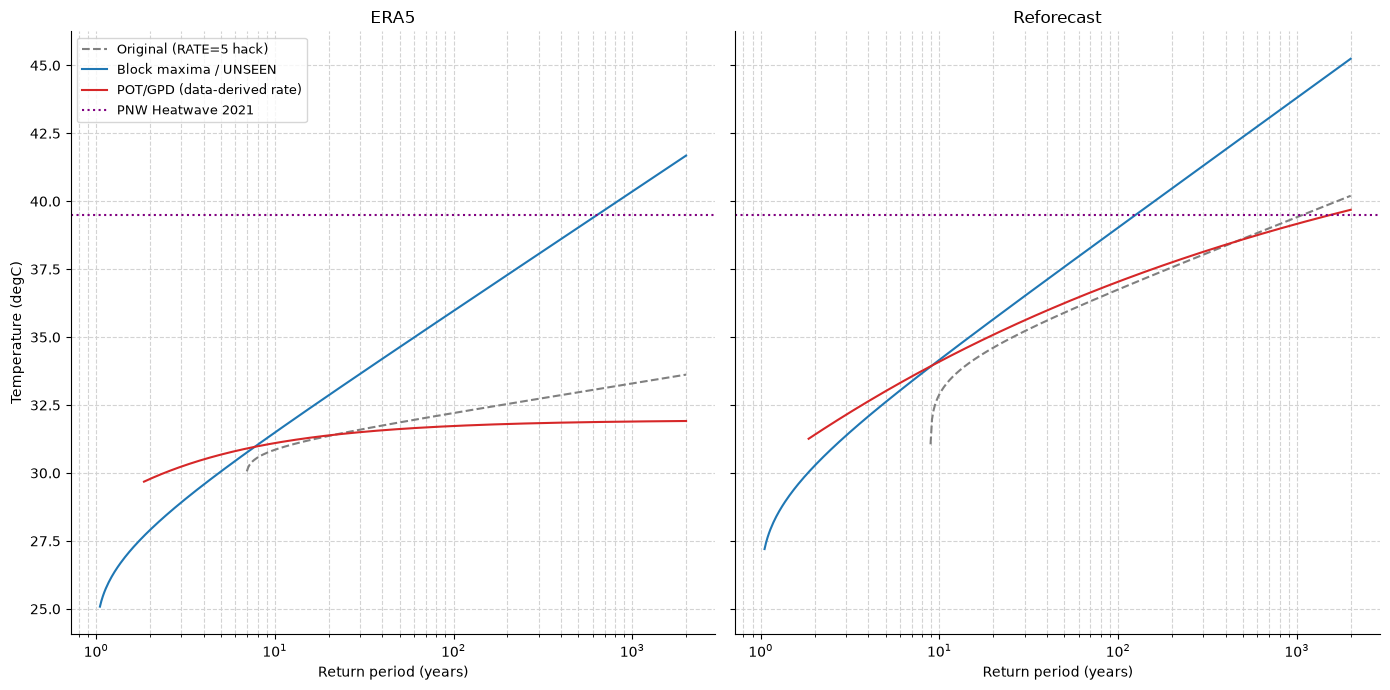

In [17]:
def _curve_original(T, gum_obj, rate, axis_scale):
    T = np.asarray(T, dtype=float)
    RP_shape = T / axis_scale
    RPs = RP_shape / rate
    with np.errstate(invalid='ignore'):
        Qs = np.where(RPs >= 1, 1 - 1 / RPs, np.nan)
        Qs_corr = (np.log(Qs) + rate) / rate
    X, a = np.median(gum_obj.X), np.median(gum_obj.a)
    return X - a * np.log(-np.log(Qs_corr))

def _curve_blockmax(T, gum_obj):
    T = np.asarray(T, dtype=float)
    F = 1 - 1 / T
    X, a = np.median(gum_obj.X), np.median(gum_obj.a)
    return X - a * np.log(-np.log(F))

def _curve_potgpd(T, gpd_obj, u, nu):
    T = np.asarray(T, dtype=float)
    with np.errstate(invalid='ignore'):
        F = 1 - 1 / (nu * T)
        F = np.where((F > 0) & (F < 1), F, np.nan)
    k, a = np.median(gpd_obj.k), np.median(gpd_obj.a)
    return u + a * (1 - (1 - F) ** k) / k

T_compare_grid = np.geomspace(1.05, 2000, 400)

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
panels = [
    (axes4[0], 'ERA5', era5_gum, era5_gum2, era5_gpd, u_era5, nu_era5, AXIS_SCALE_ERA5),
    (axes4[1], 'Reforecast', reforecast_gum, reforecast_gum2, reforecast_gpd, u_rfc, nu_rfc, AXIS_SCALE_RFC),
]
for ax, label, gum_orig, gum_bm, gpd_pot, u, nu, axis_scale in panels:
    ax.plot(T_compare_grid, _curve_original(T_compare_grid, gum_orig, RATE, axis_scale),
            color='gray', ls='--', label='Original (RATE=5 hack)')
    ax.plot(T_compare_grid, _curve_blockmax(T_compare_grid, gum_bm),
            color=color_reforecast, label='Block maxima / UNSEEN')
    ax.plot(T_compare_grid, _curve_potgpd(T_compare_grid, gpd_pot, u, nu),
            color='tab:red', label='POT/GPD (data-derived rate)')
    ax.axhline(REFERENCE_VALUE, color='purple', ls=':', label=REFERENCE_LABEL)
    ax.set_xscale('log')
    ax.set_title(label)
    ax.set_xlabel('Return period (years)')
    ax.grid(True, which='both', linestyle='--', color=grid_color)

axes4[0].set_ylabel('Temperature (degC)')
axes4[0].legend(loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('method_comparison.pdf', dpi=600)
plt.show()


### Reading the comparison

- All three curves sit close together over the range actually supported by
  data (roughly where the empirical points are) -- the methods disagree
  about *extrapolation*, not about the bulk of the fitted distribution.
- **ERA5's POT/GPD curve flattens out** near ~32 degC and never reaches the
  2021 heatwave value at all (`T_ref_era5_pot = inf` above): with only 11
  exceedances, the L-moment shape-parameter estimate happened to produce a
  distribution with a finite upper bound. That's not evidence the heatwave
  is "impossible" -- it's a symptom of how unstable a GPD shape estimate is
  with n=11, and a concrete illustration of why a single point estimate
  from a short record shouldn't be read as a hard limit.
- **ERA5's original-method curve** implies an astronomically large return
  period (>1e8 years) for the same value -- an artifact of extrapolating a
  Gumbel tail through an axis transform (the `RATE`/rescale chain) it was
  never validated against that far out, not a real statement about how rare
  the heatwave is.
- The **reforecast's three estimates are more consistent** with each other
  (order ~100-1500 years) simply because it has more data (220 vs. 20/121
  points) and the reference value is closer to, rather than far beyond, the
  fitted range.

The practical conclusion to state plainly: *the return period of an event
this extreme is method- and extrapolation-sensitive by orders of
magnitude*, and any single number quoted for it needs the fitting method
and the sample it came from stated alongside it.


## Notes / known limitations vs. the exact original PDF

- Return periods use the original notebook's `rate`/`x5` approach (Poisson
  POT correction, then rescaled by `RATE` again) for the underlying shape,
  plus a final *independent* rescale per series so ERA5's highest exceedance
  lands on 20 yr and the reforecast's lands on 220 yr. Because the two
  rescale factors differ, the reforecast curve sits at a different position
  relative to ERA5 than the single-shared-factor version did.
- The bias correction uses the corrected per-`inidate` slope/intercept values,
  now baked into `data/refore.csv` directly (see git history) -- this is what
  brings the reforecast exceedance magnitudes in line with the target figure
  (peak ~38.3 degC).
- `LEAD_DAYS=12` and `THRESHOLD_PERCENTILE=95` were hard-coded choices in the
  original analysis (not derived formulaically here) -- both are exposed at
  the top of this notebook so you can adjust them if your own methodology
  differs.
